# 📖 第一课：线性回归与最小二乘法

**目标**：理解机器学习的本质——优化；掌握最小二乘法作为线性回归的核心

---

## 1. 什么是线性回归？

线性回归 = 找一条直线 `y = kx + b`，使得所有数据点到这条直线的距离平方和最小。

- **输入**：特征 x（面积）
- **输出**：连续值 y（价格）
- **本质**：回归任务（预测连续值）

---

## 2. 房价预测示例

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 解决中文显示问题 —— 清除字体缓存并重建
import os, pathlib
cache_dir = matplotlib.get_cachedir()
for f in pathlib.Path(cache_dir).glob('fontlist*.json'):
    f.unlink()
    print(f'已删除字体缓存: {f}')

# 重建字体列表
fm._load_fontmanager(try_read_cache=False)

# 设置中文字体（按优先级排列，macOS 常见中文字体）
plt.rcParams['font.sans-serif'] = ['PingFang HK', 'PingFang SC', 'Heiti TC', 'Heiti SC', 'STHeiti', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 验证字体是否生效
chosen = plt.rcParams['font.sans-serif'][0]
matches = [f.name for f in fm.fontManager.ttflist if f.name == chosen]
print(f'matplotlib 版本: {matplotlib.__version__}')
print(f'首选字体: {chosen} → {"已找到" if matches else "未找到，尝试下一个"}')

# 数据：有噪声的房价数据
X = np.array([40, 60, 80, 100])        # 面积（㎡）
y = np.array([120, 183, 238, 302])     # 价格（万），加入了随机噪声

print("原始数据：")
for xi, yi in zip(X, y):
    print(f"  面积 {xi}㎡ → 价格 {yi}万")

已删除字体缓存: /Users/lohas/.matplotlib/fontlist-v390.json


Matplotlib is building the font cache; this may take a moment.


matplotlib 版本: 3.10.7
首选字体: PingFang HK → 已找到
原始数据：
  面积 40㎡ → 价格 120万
  面积 60㎡ → 价格 183万
  面积 80㎡ → 价格 238万
  面积 100㎡ → 价格 302万


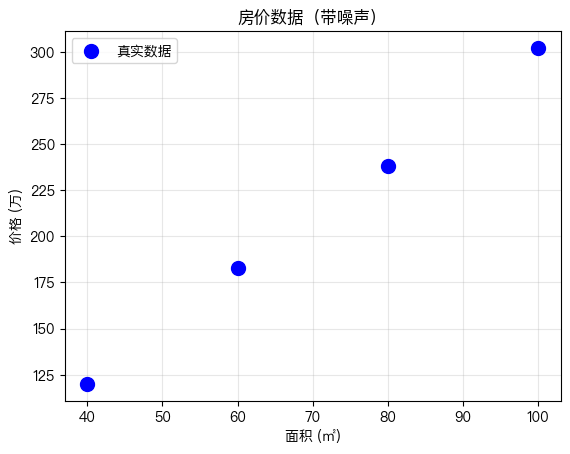

In [2]:
# 可视化原始数据点
plt.scatter(X, y, color='blue', s=100, label='真实数据', zorder=5)
plt.xlabel('面积 (㎡)')
plt.ylabel('价格 (万)')
plt.title('房价数据（带噪声）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

## 3. 用 sklearn 做线性回归

In [ ]:
# 本 cell 用于演示线性回归的基本用法
print("线性回归：最简单但最重要的机器学习算法")


In [7]:
from sklearn.linear_model import LinearRegression

# sklearn 需要二维数组
X_2d = X.reshape(-1, 1)  # shape: (4, 1)

# 创建模型并训练
model = LinearRegression()
model.fit(X_2d, y)

# 查看结果
k = model.coef_[0]      # 斜率
b = model.intercept_    # 截距

print(f"拟合结果：y = {k:.4f}x + {b:.4f}")
print(f"真实规律：y ≈ 3x（系数应为3左右）")

拟合结果：y = 3.0050x + 0.4000
真实规律：y ≈ 3x（系数应为3左右）


In [4]:
# 用模型预测
X_pred = np.array([50, 70, 90]).reshape(-1, 1)
y_pred = model.predict(X_pred)

print("预测结果：")
for xi, yi in zip(X_pred.flatten(), y_pred):
    print(f"  面积 {xi}㎡ → 价格 {yi:.1f}万")

预测结果：
  面积 50㎡ → 价格 150.7万
  面积 70㎡ → 价格 210.8万
  面积 90㎡ → 价格 270.8万


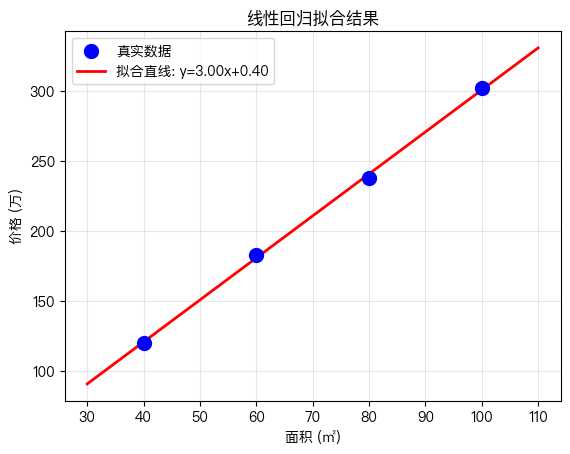

In [5]:
# 可视化拟合结果
plt.scatter(X, y, color='blue', s=100, label='真实数据', zorder=5)

X_line = np.linspace(30, 110, 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color='red', linewidth=2, label=f'拟合直线: y={k:.2f}x+{b:.2f}')

plt.xlabel('面积 (㎡)')
plt.ylabel('价格 (万)')
plt.title('线性回归拟合结果')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

## 4. 手动实现最小二乘法（不依赖 sklearn）

最小二乘法的解析解：

$k = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$，$b = \bar{y} - k\bar{x}$

In [6]:
# 手动实现最小二乘法
x_mean = np.mean(X)
y_mean = np.mean(y)

# 计算 k
numerator = np.sum((X - x_mean) * (y - y_mean))   # 分子
denominator = np.sum((X - x_mean) ** 2)            # 分母
k_manual = numerator / denominator

# 计算 b
b_manual = y_mean - k_manual * x_mean

print(f"手动计算结果：y = {k_manual:.4f}x + {b_manual:.4f}")
print(f"sklearn结果：  y = {k:.4f}x + {b:.4f}")
print(f"两者一致：{np.isclose(k_manual, k) and np.isclose(b_manual, b)}")

手动计算结果：y = 3.0050x + 0.4000
sklearn结果：  y = 3.0050x + 0.4000
两者一致：True


---

## 5. 误差分析

In [7]:
# 计算预测误差
y_pred_train = model.predict(X_2d)
errors = y - y_pred_train

print("各数据点的误差：")
for i, (xi, yi, ypi, ei) in enumerate(zip(X, y, y_pred_train, errors)):
    print(f"  点{i+1}: 真实={yi:6.1f}, 预测={ypi:6.1f}, 误差={ei:+6.1f}")

sse = np.sum(errors ** 2)  # Sum of Squared Errors
print(f"\n误差平方和 (SSE): {sse:.2f}")

各数据点的误差：
  点1: 真实= 120.0, 预测= 120.6, 误差=  -0.6
  点2: 真实= 183.0, 预测= 180.7, 误差=  +2.3
  点3: 真实= 238.0, 预测= 240.8, 误差=  -2.8
  点4: 真实= 302.0, 预测= 300.9, 误差=  +1.1

误差平方和 (SSE): 14.70


---

## 📝 课后思考

1. 如果噪声很大（比如±50万的随机波动），拟合效果会差多少？
2. 如果特征不止一个（面积+地段+楼层），直线会变成什么？
3. 当数据不是线性分布时，线性回归还适用吗？

---

**下一步**：梯度下降——当解析解算不出来时（高维、复杂模型），如何通过迭代找到最优参数。